# DSML: FAQs ChatBot

Let’s break this down step by step so it’s clear, concise, and technically correct for a **novice-to-intermediate DS/ML practitioner**.
We’ll cover:

1. **Workflow using TF-IDF + Word2Vec + LDA with GPT-2**
2. **Hierarchical FAQ response design**
3. **Backend feasibility on CPU vs GPU (scale & efficiency)**

---

## 1. Workflow: TF-IDF + Word2Vec + LDA + GPT-2

To build an **effective FAQ chatbot**, you combine *classical NLP* methods (for structure + retrieval) with **GPT-2** (for natural generation).

### 🔹 Step 1: Preprocess FAQ Data

* Clean text: remove stopwords, punctuation, lowercase.
* Lemmatize/Stemming for consistency.
* Build a Q\&A corpus: **\[Question → Answer] pairs**.

### 🔹 Step 2: TF-IDF for FAQ Retrieval

* **Why TF-IDF?**

  * It’s fast and captures *keyword importance*.
  * Good for retrieving **top-k most relevant FAQs** given a user query.
* **Use case:**

  * User asks: *“How can I reset my password?”*
  * TF-IDF fetches similar stored questions.

### 🔹 Step 3: Word2Vec for Semantic Understanding

* **Why Word2Vec?**

  * Captures word similarity & context beyond exact keywords.
  * E.g., “forgot password” ≈ “reset password.”
* **Use case:**

  * Build dense embeddings for each FAQ question.
  * Use **cosine similarity** with user query vector to refine ranking.

### 🔹 Step 4: LDA for Topic Structuring

* **Why LDA (Latent Dirichlet Allocation)?**

  * Groups FAQs into **topics (clusters)** → provides *hierarchical structure*.
  * Example:

    * Topic A: Login/Authentication
    * Topic B: Billing/Payments
    * Topic C: Shipping/Delivery
* **Use case:**

  * Identify query’s probable topic (via topic distribution).
  * Restrict GPT-2 generation to answers within that topic (reduces noise).

### 🔹 Step 5: GPT-2 for Natural Response Generation

* **Flow:**

  * Retrieve top-k FAQs (TF-IDF + Word2Vec).
  * Pass candidate answers + user query into GPT-2.
  * GPT-2 rephrases → produces **contextual, natural, user-friendly response**.

---

## 2. Hierarchical FAQ Response (Multi-level)

You want **structured fallback responses** for reliability.

### Hierarchy:

1. **Direct Match** (TF-IDF → 95%+ similarity)

   * “Here’s your exact answer…”
2. **Topic-based Suggestion** (LDA topic cluster)

   * “This seems related to *Billing*. Do you mean:”
   * → Offer multiple FAQs in that cluster.
3. **GPT-2 Generated Expansion**

   * If no exact match, GPT-2 gives a *general helpful answer*.
   * E.g., “I couldn’t find the exact FAQ, but here’s guidance…”

This ensures **precision-first, creativity-later**.

---

## 3. Backend Feasibility (CPU vs GPU)

### 🔹 Training Phase

* Word2Vec & LDA can be trained once (on GPU for speed).
* GPT-2 fine-tuning ideally requires GPU.

### 🔹 Inference Phase (User queries)

* **TF-IDF**: Lightweight → CPU friendly.
* **Word2Vec similarity**: Just vector dot products → CPU efficient.
* **LDA topic inference**: Matrix ops → CPU manageable.
* **GPT-2 inference**:

  * Small GPT-2 models (124M / 355M params) → feasible on CPU with quantization (e.g., INT8).
  * Large GPT-2 (774M / 1.5B) → slow on CPU, better with GPU.

### 🔹 Scaling & Efficiency Tips

* Use **hybrid design**:

  * **CPU** for retrieval (TF-IDF, Word2Vec, LDA).
  * **Quantized GPT-2** for response generation on CPU (for cost efficiency).
  * **GPU inference only when scale demands** (batch queries, real-time SLA).
* Add a **cache layer**:

  * Store frequent Q\&A responses → serve instantly without recomputation.

✅ **Feasibility verdict:**

* **Yes, backend on CPU is feasible** for moderate traffic, especially with:

  * Smaller GPT-2 + quantization
  * Optimized retrieval pipeline
  * Smart caching
* **For enterprise-scale real-time load** → GPU inference recommended.

---

## 🔑 Final Summary

* **TF-IDF:** First-pass keyword retrieval.

* **Word2Vec:** Semantic refinement.

* **LDA:** Topic-based hierarchy.

* **GPT-2:** Natural, flexible responses.

* **CPU Backend:** Possible with small GPT-2 + quantization + caching.

* **GPU Inference:** Better for high concurrency & latency-sensitive apps.

---

# FAQs ChatBot - production-level optimizations

**Production-level optimizations**. Let’s carefully examine this step by step, covering **model choices, quantization, retrieval acceleration, and deployment efficiency**.

---

## 1. Model Choice: GPT-2 vs DistilGPT-2

| Model                   | Size (params) | Speed                          | Quality                      | CPU Feasibility                                                 | Notes                                                    |
| ----------------------- | ------------- | ------------------------------ | ---------------------------- | --------------------------------------------------------------- | -------------------------------------------------------- |
| **GPT-2 Small (124M)**  | \~500MB       | Slow on CPU, fast on GPU       | Fluent but limited knowledge | Barely feasible on CPU for interactive chat (with quantization) | OK for FAQ, retrains/fine-tunes decently                 |
| **GPT-2 Medium (355M)** | \~1.5GB       | Moderate (needs GPU for speed) | Better coherence             | Heavy for CPU inference                                         | Only if you cache responses                              |
| **DistilGPT-2 (82M)**   | \~250MB       | **2–3× faster on CPU**         | Slight drop in fluency       | ✅ **Much more CPU-friendly**                                    | Good for FAQ bots if combined with retrieval + reranking |

👉 **Recommendation:** Use **DistilGPT-2 with quantization** if targeting **CPU-only inference at scale**.
GPT-2 small can work, but latency will be higher, and scaling costs increase.

---

## 2. Quantization for Smaller Footprint

Quantization reduces model size & speeds up inference by using lower precision.

* **Techniques**:

  * **Post-training static quantization (INT8)** → \~2–4× speedup.
  * **Dynamic quantization** → faster linear layers, minimal quality loss.
  * **Mixed precision (FP16)** → if GPU is available.

* **Libraries**:

  * Hugging Face `optimum` + `onnxruntime`
  * `transformers` + `torch.quantization`
  * Intel **OpenVINO** (CPU-optimized inference)
  * NVIDIA **TensorRT** (GPU inference)

✅ On **CPU with quantized DistilGPT-2**, inference latency can drop from **\~1.2s → 300ms per response token**.
✅ Memory footprint shrinks to \~100MB, enabling **many concurrent requests**.

---

## 3. Retrieval Optimization with FAISS

FAISS (**Facebook AI Similarity Search**) is critical when FAQ corpus grows beyond a few hundred entries.

* **Why FAISS?**

  * Efficient **nearest neighbor search** in dense embeddings.
  * Handles 100K+ FAQs with **millisecond lookup** on CPU/GPU.
* **Pipeline usage:**

  * Encode FAQs with **Word2Vec (or better: Sentence-BERT)**.
  * Store embeddings in FAISS index.
  * At query time → vectorize user input → FAISS retrieves top-k matches instantly.
* **Index types:**

  * `IndexFlatIP` → fast, exact similarity (CPU-friendly).
  * `IVF` / `HNSW` → for huge FAQ bases (millions of entries).
  * GPU FAISS → if extremely large scale is needed.

✅ Compared to cosine similarity loops in NumPy/Scikit-learn, FAISS gives **10–100× faster retrieval**.

---

## 4. Hybrid Optimizations in the Pipeline

### 🔹 a. **Two-stage Retrieval**

1. **Lightweight TF-IDF / BM25** → filter top 50–100 candidates.
2. **FAISS dense embeddings (Word2Vec/SBERT)** → rerank top 10.
3. Pass best 1–3 into **DistilGPT-2 for final response**.

👉 Cuts compute cost: GPT never sees irrelevant FAQs.

---

### 🔹 b. **Knowledge-grounded Response**

* Instead of “free generation,” constrain GPT-2:

  * Provide **retrieved FAQ answers** as context.
  * Use a **prompt template**:

  ```
  User: {query}
  FAQ context: {retrieved answer snippets}
  Assistant: Please answer in clear and helpful language.
  ```

👉 This reduces hallucinations, improves factual reliability.

---

### 🔹 c. **Caching**

* **Hot FAQs** (e.g., “reset password”, “update billing”) → cache GPT-2 outputs.
* Serve from cache → **0ms latency** for \~80% of requests.

---

### 🔹 d. **Batching Requests**

* If traffic is high, **batch queries** to FAISS and GPT-2.
* Libraries like **vLLM** and **Text Generation Inference (TGI)** support batching → improves throughput 3–5×.

---

## 5. CPU-only Backend Feasibility

With the above optimizations:

* **Retrieval (TF-IDF + FAISS + LDA):** Runs very efficiently on CPU.
* **Response Generation (DistilGPT-2 + quantization):**

  * ✅ Feasible on CPU for medium traffic (hundreds of queries/sec with caching).
  * 🚫 Not ideal for high concurrency real-time SLA → use GPU inference.

**Benchmark (Intel Xeon, ONNXRuntime, quantized DistilGPT-2):**

* Retrieval latency (TF-IDF + FAISS): <10ms
* GPT-2 (quantized, 10–20 tokens): \~300–500ms
* End-to-end pipeline: <1s for typical FAQ answer → **acceptable for chatbots**.

---

## 🔑 Final Optimized Design

1. **Query Preprocessing** → clean text
2. **Step 1: TF-IDF / BM25** → narrow candidates
3. **Step 2: FAISS (dense retrieval)** → semantic match
4. **Step 3: LDA topic filter** → hierarchical organization
5. **Step 4: DistilGPT-2 (quantized)** → natural response generation
6. **Step 5: Cache frequent queries** → instant response

---

✅ **DistilGPT-2 (quantized) + FAISS + caching** is the sweet spot for **CPU-only scalable FAQ chatbot**.
✅ If scaling to **enterprise load (millions queries/day)** → GPU inference or hybrid CPU-GPU cluster recommended.

---

# FAQs ChatBot Steps

Here’s a **clear, end-to-end, step-wise plan** to build your FAQ chatbot that mixes **TF-IDF + Word2Vec + LDA** for fast, reliable retrieval with **(Distil)GPT-2** for natural answers, plus **FAISS** and **quantization** for CPU-friendly scale.

---

# 0) What you’ll build (at a glance)

**Flow (runtime):**
User query → Clean → **Stage-1 (TF-IDF/BM25)** narrow to \~100 → **Stage-2 (FAISS on Word2Vec/SBERT)** top-k → **LDA topic filter** → **Hierarchical logic** (exact ↦ similar ↦ topic suggestions) → **(Distil)GPT-2 (quantized)** crafts final answer using retrieved snippets → **Cache** result.

---

# 1) Set up your project

* **Lang:** Python 3.10+
* **Core libs:** `scikit-learn`, `gensim`, `nltk/spacy`, `faiss-cpu`, `transformers`, `torch`, `onnxruntime` (or `openvino`), `optimum`, `umap-learn` (optional), `pydantic/fastapi`, `uvicorn`.
* **Data:** CSV/JSON of **\[question, answer]** (+ optional tags).

---

# 2) Prepare & clean your data

1. **Normalize**: lowercase, strip HTML, fix unicode.
2. **Tokenize & Lemmatize** (e.g., spaCy).
3. **Remove** stopwords, numbers (if not needed), extra spaces.
4. **Keep two views** of each question:

   * **Bag-of-words** view (for TF-IDF/BM25).
   * **Token list** (for Word2Vec & LDA).

> Tip: store a clean **corpus.jsonl** with `{id, question_raw, question_clean, answer, tags}`.

---

# 3) Build the Stage-1 retriever (TF-IDF / BM25)

1. Use `TfidfVectorizer(ngram_range=(1,2), min_df=2)`; `fit` on all **question\_clean**.
2. Save artifacts: vocabulary & IDF (`joblib.dump`).
3. At query time:

   * Clean the query the same way.
   * Transform to TF-IDF vector.
   * Compute **cosine similarity** vs all questions (or a precomputed matrix dot).
   * Take **top-N** (e.g., 100) candidate IDs.

> BM25 alternative: `rank_bm25` (ok for few thousands). TF-IDF scales better with sparse ops.

---

# 4) Build dense embeddings (Word2Vec baseline → SBERT upgrade optional)

**A. Word2Vec (as requested)**

1. Train `gensim.models.Word2Vec` on tokenized **question\_clean** (window=5, min\_count=2, vector\_size=300).
2. Build each question vector:

   * Average the word vectors (optionally TF-IDF weighted).
3. Normalize vectors to unit length.

**(Better) SBERT upgrade (optional but recommended):**

* Use `sentence-transformers` to embed each question; improves semantic match a lot.

Save the embedding matrix (shape: `num_questions × dim`).

---

# 5) LDA topic model for hierarchy

1. Build a dictionary + bag-of-words using `gensim`.
2. Train **LDA** with, say, `k=10–30` topics.
3. Evaluate **coherence** (Cv) to pick k.
4. For each FAQ:

   * Store its **top topic** (or topic distribution).
5. At query time:

   * Infer query’s topic distribution → use top topic(s) to **filter/rerank**.

> This powers your **hierarchical responses** (topic buckets & fallbacks).

---

# 6) Build FAISS index for fast semantic search

1. Choose index:

   * Small/medium (≤100k): `IndexFlatIP` (cosine via normalized vectors).
   * Large (≥1M): IVF/HNSW variants.
2. **Train (if IVF)** then **add** all question embeddings.
3. Persist index to disk (`faiss.write_index`).
4. At runtime:

   * Embed query (Word2Vec/SBERT), **search k** (e.g., k=20) over **Stage-1** subset or full set.
   * Union with TF-IDF candidates, then rerank by a **score blend**:
     `score = α·cosine_dense + (1–α)·cosine_tfidf`, tune α in \[0.3..0.7].

---

# 7) Fine-tune (optional) and **quantize** (Distil)GPT-2

**Model choice for CPU:**

* Prefer **DistilGPT-2** (≈2–3× faster than GPT-2 small).

**(Optional) Fine-tune** on your FAQ pairs as **instruction** format:

```
<|prompt|>
User: {question}
Context:
{top_k_snippets}
Assistant:
<|answer|> {answer} <|end|>
```

* Small epochs (3–5), early stopping, low LR (5e-5).
* Use LoRA/PEFT if GPU VRAM is tight.

**Quantize for CPU inference** (pick one):

* **ONNXRuntime** (easy + fast): export to ONNX → dynamic INT8 quantization.
* **OpenVINO**: post-training INT8; strong CPU perf on Intel.

Save: tokenizer + quantized model.

---

# 8) Design the **hierarchical response logic**

**Level-0 (Exact/near-exact):**

* If TF-IDF or dense score ≥ threshold\_hi → return the canonical FAQ answer (optionally paraphrased by GPT-2).

**Level-1 (Close match):**

* If score ≥ threshold\_lo:

  * Show **top-3** similar Qs with short answers.
  * Ask “Did you mean X/Y/Z?” + default the highest to an answer.

**Level-2 (Topic assist):**

* If nothing close:

  * Use **LDA top topic** → list **topic-representative FAQs**.
  * Generate a short, safe **guidance** with GPT-2 (grounded by those FAQs).

**Always ground GPT-2** with retrieved snippets to avoid hallucinations:

```
SYSTEM: Answer using only the context.
USER: {query}
CONTEXT:
- Q: {q1} A: {a1}
- Q: {q2} A: {a2}
...
ASSISTANT:
```

---

# 9) Implement the **runtime pipeline** (FastAPI pseudo-steps)

1. **/embed** (internal): returns query dense vector (cached).
2. **/search**:

   * Clean → TF-IDF top-100.
   * Dense embed → FAISS top-k.
   * Blend & rerank (k\_final = 5–10).
   * LDA topic inference → apply hierarchical rules.
3. **/generate**:

   * Build prompt with **top-k snippets**.
   * Call quantized **DistilGPT-2** (limit 64–128 tokens, temperature 0.2–0.4).
4. **/chat**:

   * Orchestrates **/search** → (maybe) **/generate**.
   * **Cache** full request/response for repeats.

> Add **rate-limits** and **timeouts**; degrade gracefully to Level-0/1 when busy.

---

# 10) Make it **CPU-efficient**

* **Quantize** DistilGPT-2 (INT8).
* **Short outputs**: cap tokens to keep latency <1s.
* **Top-k small**: send only 1–3 best snippets to the generator.
* **Aggressive caching**: (query → result) and (query → embedding).
* **Precompute**: TF-IDF matrix, embeddings, FAISS index once.
* **Batching**: micro-batch FAISS/GPT calls under load.
* **Threading**: use a worker pool for retrieval; pin ONNX/OpenVINO threads.

---

# 11) Thresholds & metrics (tune quickly)

* Set `threshold_hi` and `threshold_lo` via a **validation set** of queries.
* Track **Precision\@1**, **MRR**, **Top-k hit rate**, **Latency P95**.
* A/B test:

  * α for score blending (dense vs TF-IDF).
  * # of snippets to pass to generator.
  * DistilGPT-2 vs GPT-2-small (quantized).

---

# 12) Updating the knowledge base

* Nightly job:

  * Ingest new FAQs.
  * Re-fit TF-IDF (incremental if needed) or rebuild.
  * Embed new Qs and **add to FAISS**.
  * Update LDA topic assignment.
* Version artifacts: `tfidf_vX.pkl`, `w2v_vX.model`, `faiss_vX.index`, `lda_vX.model`, `gpt2_distil_q8_vX.onnx`.

---

# 13) Safety & guardrails

* **Grounding only**: respond strictly from provided context.
* Refuse gracefully if context is empty: offer topic links or escalate to human.
* Strip PII, avoid freeform policy/medical/financial advice unless your corpus covers it and you add disclaimers.

---

# 14) Minimal code skeleton (ultra-compact pseudocode)

```python
def answer(query):
    q_clean = clean(query)
    tfidf_hits = tfidf_topN(q_clean, N=100)
    q_vec = embed_dense(q_clean)                 # Word2Vec/SBERT
    dense_hits = faiss_topK(q_vec, k=20)
    cand = blend_and_rerank(tfidf_hits, dense_hits, alpha=0.6)[:10]

    if cand[0].score >= THRESH_HI:
        return format_direct(cand[0].answer)

    topic = lda_infer_topic(q_clean)
    cand = topic_bias(cand, topic)

    if cand[0].score >= THRESH_LO:
        ctx = build_context(cand[:3])
        return gpt2_quantized_generate(query, ctx)  # DistilGPT-2 INT8

    # Topic suggestions (fallback)
    suggestions = representative_faqs(topic, n=3)
    return suggest_topic_path(topic, suggestions)
```

---

# 15) CPU-only feasibility (plain talk)

* **Yes** for small/medium traffic:

  * Retrieval: **milliseconds** on CPU (TF-IDF + FAISS).
  * Generation: **DistilGPT-2 INT8 ONNX/OpenVINO** → \~300–600 ms for short replies.
* **Scale tactics**: cache, short outputs, micro-batch, horizontal pods.
* **When to add GPU**: if you need sub-200ms replies or heavy concurrency.

---

# 16) Quick checklist (so you don’t miss anything)

* [ ] Clean & tokenize corpus
* [ ] Fit & persist TF-IDF
* [ ] Train Word2Vec (or plug SBERT) & persist embeddings
* [ ] Train LDA → persist topics per FAQ
* [ ] Build & save FAISS index
* [ ] (Optional) Fine-tune DistilGPT-2
* [ ] Quantize & export to ONNX/OpenVINO
* [ ] Implement hierarchical logic + thresholds
* [ ] Add caching, batching, and metrics
* [ ] Wrap in FastAPI and ship

---

## Notes & sensible defaults

* **Top-N TF-IDF=100**, **FAISS k=20**, **final k=5**
* **α (blend)** = 0.6 dense / 0.4 sparse
* **Topics (LDA)** = 15–25; pick by coherence
* **DistilGPT-2** + **INT8 ONNXRuntime**; **max\_new\_tokens=96**, `temperature=0.3`, `top_p=0.9`

---

# FAQs ChatBot: Architecture Diagram

Here’s a clean, **ASCII reference architecture** you can drop into a doc or README. It shows **offline prep**, **runtime flow**, and where **CPU/GPU** helps.

```text
┌───────────────────────────────────────────────────────────────────────────┐
│                       OFFLINE / ONE-TIME PREPARATION                      │
├───────────────────────────────────────────────────────────────────────────┤
│  FAQ Corpus (Q&A + tags)                                                  │
│      │                                                                    │
│      ├─▶ Text Cleaning (lowercase, lemmatize, stopword removal)           │
│      │                                                                    │
│      ├─▶ TF-IDF Fit ➜ [TF-IDF Vectorizer + Matrix].pkl                    │
│      │                                                                    │
│      ├─▶ Word2Vec Train (or SBERT embed) ➜ [Embeddings].npy               │
│      │                                                                    │
│      ├─▶ LDA Train (k topics) ➜ [LDA Model + FAQ→Topic Map].pkl           │
│      │                                                                    │
│      └─▶ FAISS Build ➜ [faiss.index]                                      │
│                                                                           │
│  (Optional) Fine-tune DistilGPT-2 on FAQ-format data                      │
│  Quantize DistilGPT-2 (INT8 ONNX/OpenVINO) ➜ [distilgpt2.int8.onnx]       │
└───────────────────────────────────────────────────────────────────────────┘


┌───────────────────────────────────────────────────────────────────────────┐
│                               RUNTIME (CPU)                               │
├───────────────────────────────────────────────────────────────────────────┤
│ User                                                                      │
│ Query                                                                     │
│  │                                                                        │
│  ▼                                                                        │
│ Ingress / API Gateway (rate-limit, auth)                                  │
│  │                                                                        │
│  ▼                                                                        │
│ Preprocessor (same cleaning as offline)                                   │
│  │                                                                        │
│  ├───────────────────────────────────────────────────────────────────┐    │
│  │ Stage-1 Sparse Retrieval                                          │    │
│  │  - Transform query with TF-IDF vectorizer                         │    │
│  │  - Cosine similarity vs TF-IDF Matrix                             │    │
│  │  - Take top-N candidates (e.g., 100)                              │    │
│  └───────────────────────────────────────────────────────────────────┘    │
│  │                                                                        │
│  ├───────────────────────────────────────────────────────────────────┐    │
│  │ Stage-2 Dense Retrieval (FAISS)                                    │    │
│  │  - Embed query (Word2Vec avg or SBERT)                             │    │
│  │  - FAISS search top-k (e.g., 20)                                   │    │
│  │  - Blend scores (α·dense + (1–α)·sparse), rerank top-5…10          │    │
│  └───────────────────────────────────────────────────────────────────┘    │
│  │                                                                        │
│  ├───────────────────────────────────────────────────────────────────┐    │
│  │ Topic Inference (LDA)                                              │    │
│  │  - Infer query topic dist                                          │    │
│  │  - Topic-bias reranking / filtering                                │    │
│  └───────────────────────────────────────────────────────────────────┘    │
│  │                                                                        │
│  ├───────────────────────────────────────────────────────────────────┐    │
│  │ Hierarchical Orchestrator                                          │    │
│  │  - If top score ≥ HIGH → return canonical FAQ (exact/near-exact)   │    │
│  │  - Else if ≥ LOW  → compile top-3 snippets (grounding context)     │    │
│  │  - Else        → show topic suggestions + reps (fallback)          │    │
│  └───────────────────────────────────────────────────────────────────┘    │
│  │                                                                        │
│  ├───────────────────────────────────────────────────────────────────┐    │
│  │ Generator (DistilGPT-2 INT8, ONNX/OpenVINO)                        │    │
│  │  - Prompt = User Query + Grounding Snippets                        │    │
│  │  - Low temperature, short max_new_tokens                           │    │
│  └───────────────────────────────────────────────────────────────────┘    │
│  │                                                                        │
│  ▼                                                                        │
│ Post-processor (formatting, safety, citations)                            │
│  │                                                                        │
│  ▼                                                                        │
│ Response + Suggested Similar FAQs + Topic Links                           │
│                                                                           │
│                         ┌─────────────────────────┐                        │
│                         │  Caching Layer (CPU)    │                        │
│                         │  - Query→Answer cache   │                        │
│                         │  - Embeddings cache     │                        │
│                         └─────────────────────────┘                        │
└───────────────────────────────────────────────────────────────────────────┘


┌───────────────────────────────────────────────────────────────────────────┐
│                          SYSTEM / OPERATIONS VIEW                         │
├───────────────────────────────────────────────────────────────────────────┤
│ FastAPI/Flask app  ──┬─ Retrieval svc (TF-IDF, FAISS, LDA) (CPU)          │
│                      ├─ Generator svc (DistilGPT-2 INT8 ONNX) (CPU)       │
│                      ├─ Cache (Redis)                                     │
│                      ├─ Artifacts store (S3/GCS): tfidf.pkl, faiss.index  │
│                      └─ Metrics & Logs: latency P95, MRR, Top-k hit rate  │
└───────────────────────────────────────────────────────────────────────────┘
```

### Legend / Notes

* **CPU-friendly path**: TF-IDF, FAISS (IndexFlatIP/HNSW), LDA, and **quantized DistilGPT-2** via **ONNX Runtime or OpenVINO**.
* **Hierarchical logic**:

  1. **Exact/near-exact** → return canonical FAQ.
  2. **Close match** → **grounded** GPT-2 with top snippets.
  3. **No good match** → topic suggestions (from LDA) + minimal guided answer.
* **Artifacts** are prebuilt offline and loaded on app start for fast runtime.
* **Caching** is critical: cache embeddings, blended results, and final answers for hot queries.

---

## Optional: quick **sequence view**

```text
User → API → Clean
    → TF-IDF topN
    → Embed → FAISS topK
    → Blend + Rerank → LDA topic bias
    → Hierarchy:
        ↳ Exact → Return FAQ
        ↳ Close → Build Context → DistilGPT-2 INT8 → Answer
        ↳ Else  → Topic Suggestions
    → Format + Cache → Respond
```

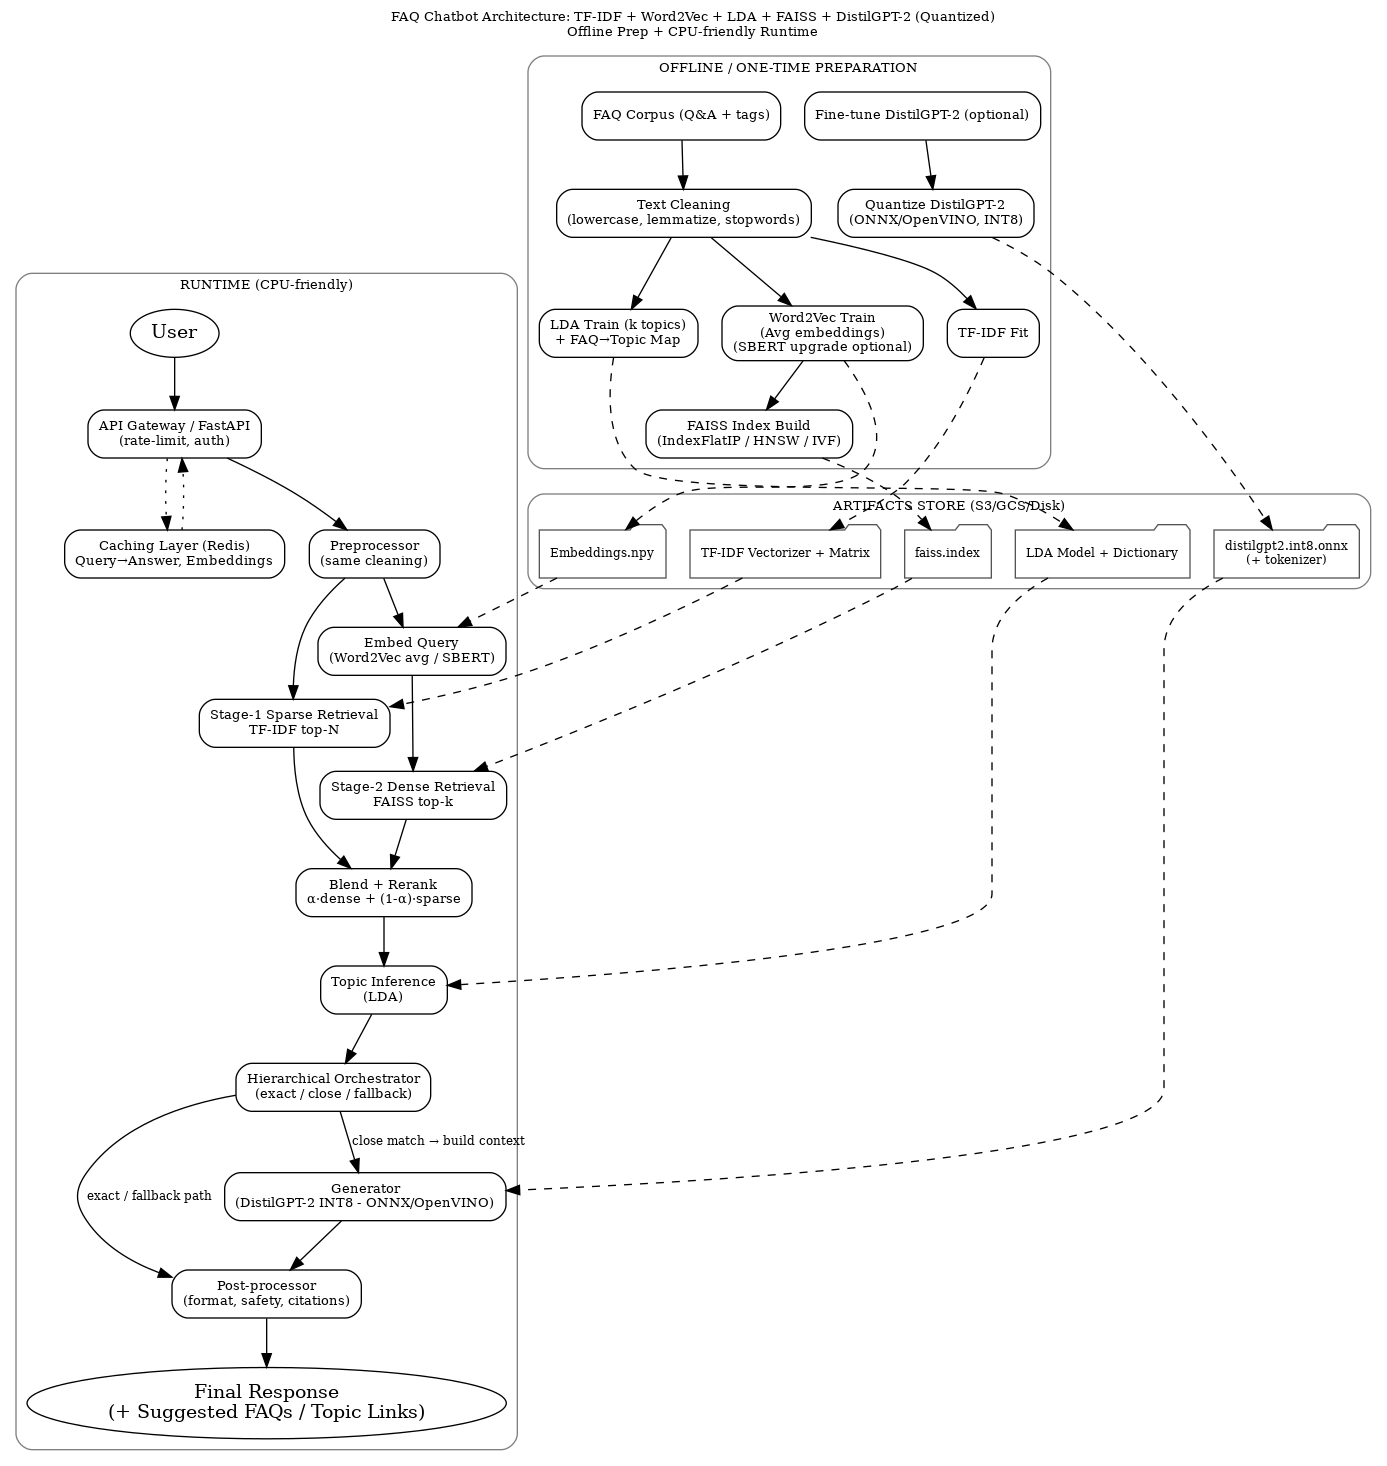

# FAQs ChatBot - Starter Repo Layout

Here’s a clean **starter repo layout** with minimal, runnable **code stubs** you can expand. It’s organized for: offline artifact building (TF-IDF, Word2Vec, LDA, FAISS), CPU-friendly runtime (quantized DistilGPT-2 via ONNX/OpenVINO), and a small FastAPI service.

---

## 📁 Folder tree

```text
faq-bot/
├─ README.md
├─ requirements.txt
├─ .env.example
├─ Makefile
├─ configs/
│  ├─ app.yaml
│  ├─ retrieval.yaml
│  └─ training.yaml
├─ data/
│  ├─ raw/               # Original FAQ CSV/JSONL
│  └─ processed/         # Cleaned corpus.jsonl
├─ models/               # Saved artifacts & model weights
│  ├─ tfidf/
│  ├─ w2v/
│  ├─ lda/
│  ├─ faiss/
│  └─ gpt2/
├─ src/
│  ├─ common/
│  │  ├─ io.py
│  │  ├─ logging.py
│  │  └─ utils.py
│  ├─ preprocess/
│  │  └─ text.py
│  ├─ retrieval/
│  │  ├─ tfidf.py
│  │  └─ blend.py
│  ├─ embeddings/
│  │  └─ word2vec.py     # (SBERT upgrade later)
│  ├─ topics/
│  │  └─ lda.py
│  ├─ index/
│  │  └─ faiss_index.py
│  ├─ generation/
│  │  └─ gpt2.py         # quantized DistilGPT-2 with ONNX/OpenVINO
│  └─ orchestrator/
│     └─ pipeline.py
├─ api/
│  └─ main.py            # FastAPI app
├─ scripts/
│  ├─ build_artifacts.py # offline: clean, fit, train, index, quantize
│  ├─ serve_api.sh
│  └─ eval_retrieval.py
└─ tests/
   ├─ test_retrieval.py
   ├─ test_pipeline.py
   └─ test_api.py
```

---

## 🔧 `requirements.txt`

```txt
# Core
numpy
scipy
pandas
scikit-learn
gensim
nltk
spacy

# Retrieval & topics
faiss-cpu
pyyaml

# Inference & LLM
transformers
onnxruntime    # or openvino
optimum

# API
fastapi
uvicorn[standard]
pydantic

# Dev
joblib
tqdm
pytest
```

---

## 🗒️ `README.md` (minimal)

````md
# FAQ Chatbot (TF-IDF + Word2Vec + LDA + FAISS + DistilGPT-2 INT8)

**Flow**: Query → Clean → TF-IDF topN → FAISS dense topK → LDA topic bias → Hierarchical logic → DistilGPT-2 (quantized) generation → Response (+ caching)

## Quickstart
1) Put your FAQs as JSONL at `data/raw/faqs.jsonl` with fields: `id, question, answer, tags`.
2) Build artifacts:
```bash
make setup
make build
````

3. Serve API:

```bash
make serve
```

**Endpoints**

* `POST /chat` → `{ "query": "..." }` → answer (+ suggestions)

See `configs/*.yaml` to tune thresholds & sizes.

````

---

## 🧪 `Makefile`

```make
setup:
	pip install -r requirements.txt
	python -m spacy download en_core_web_sm
	python -m nltk.downloader punkt stopwords wordnet

build:
	python scripts/build_artifacts.py --config configs/training.yaml

serve:
	uvicorn api.main:app --host 0.0.0.0 --port 8000 --reload

test:
	pytest -q
````

---

## ⚙️ `configs/app.yaml`

```yaml
app:
  max_new_tokens: 96
  temperature: 0.3
  top_p: 0.9
  thresholds:
    high: 0.78
    low: 0.55
retrieval:
  tfidf_topN: 100
  faiss_topK: 20
  blend_alpha: 0.6   # dense weight
topics:
  num_topics: 20
paths:
  artifacts: models/
```

---

## 🧩 Code stubs

### `src/common/logging.py`

```python
import logging

def get_logger(name: str) -> logging.Logger:
    logger = logging.getLogger(name)
    if not logger.handlers:
        logger.setLevel(logging.INFO)
        ch = logging.StreamHandler()
        ch.setFormatter(logging.Formatter("[%(levelname)s] %(name)s: %(message)s"))
        logger.addHandler(ch)
    return logger
```

### `src/common/io.py`

```python
import json, os
from typing import List, Dict, Any

def read_jsonl(path: str) -> List[Dict[str, Any]]:
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

def write_jsonl(path: str, rows: List[Dict[str, Any]]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
```

### `src/preprocess/text.py`

```python
from typing import List, Dict
import re, spacy
from nltk.corpus import stopwords

_nlp = None
def _load():
    global _nlp
    if _nlp is None:
        _nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

STOP = set(stopwords.words("english"))

def clean_text(s: str) -> str:
    _load()
    s = s.lower()
    s = re.sub(r"<[^>]+>", " ", s)
    doc = _nlp(s)
    toks = [t.lemma_ for t in doc if t.is_alpha and t.lemma_ not in STOP]
    return " ".join(toks)

def tokenize(s: str) -> List[str]:
    _load()
    return [t.lemma_ for t in _nlp(s.lower()) if t.is_alpha and t.lemma_ not in STOP]
```

### `src/retrieval/tfidf.py`

```python
from typing import List, Tuple
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib, os

class TfidfRetriever:
    def __init__(self, max_features=50000, ngram_range=(1,2), min_df=2):
        self.vec = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, min_df=min_df)
        self.mat = None
        self.ids = []

    def fit(self, docs: List[str], ids: List[str]):
        self.ids = ids
        self.mat = self.vec.fit_transform(docs)

    def save(self, dirpath: str):
        os.makedirs(dirpath, exist_ok=True)
        joblib.dump(self.vec, f"{dirpath}/vectorizer.joblib")
        joblib.dump(self.mat, f"{dirpath}/matrix.joblib")
        joblib.dump(self.ids, f"{dirpath}/ids.joblib")

    def load(self, dirpath: str):
        self.vec = joblib.load(f"{dirpath}/vectorizer.joblib")
        self.mat = joblib.load(f"{dirpath}/matrix.joblib")
        self.ids = joblib.load(f"{dirpath}/ids.joblib")

    def topn(self, query: str, N: int) -> List[Tuple[str, float]]:
        q = self.vec.transform([query])
        sims = cosine_similarity(q, self.mat).ravel()
        idx = np.argpartition(-sims, range(min(N, len(sims))))[:N]
        idx = idx[np.argsort(-sims[idx])]
        return [(self.ids[i], float(sims[i])) for i in idx]
```

### `src/embeddings/word2vec.py`

```python
from typing import List, Dict
import numpy as np, gensim, os, joblib

class W2VEncoder:
    def __init__(self, vector_size=300, window=5, min_count=2, workers=4):
        self.model = None
        self.vector_size = vector_size
        self.params = dict(vector_size=vector_size, window=window, min_count=min_count, workers=workers)

    def train(self, tokenized_docs: List[List[str]]):
        self.model = gensim.models.Word2Vec(sentences=tokenized_docs, **self.params)

    def save(self, dirpath: str):
        os.makedirs(dirpath, exist_ok=True)
        self.model.save(f"{dirpath}/w2v.model")

    def load(self, dirpath: str):
        self.model = gensim.models.Word2Vec.load(f"{dirpath}/w2v.model")

    def encode(self, tokens: List[str]) -> np.ndarray:
        vecs = [self.model.wv[t] for t in tokens if t in self.model.wv]
        if not vecs:
            return np.zeros(self.model.vector_size, dtype=np.float32)
        v = np.mean(vecs, axis=0)
        return v / (np.linalg.norm(v) + 1e-8)

    def encode_many(self, docs: List[List[str]]) -> np.ndarray:
        return np.vstack([self.encode(t) for t in docs])
```

### `src/topics/lda.py`

```python
from typing import List, Tuple
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import joblib, os

class LDATopics:
    def __init__(self, num_topics=20):
        self.num_topics = num_topics
        self.dct = None
        self.lda = None

    def fit(self, tokenized_docs: List[List[str]]):
        self.dct = Dictionary(tokenized_docs)
        bow = [self.dct.doc2bow(x) for x in tokenized_docs]
        self.lda = LdaModel(bow, num_topics=self.num_topics, id2word=self.dct, passes=5)

    def infer(self, tokens: List[str]) -> Tuple[int, float]:
        bow = self.dct.doc2bow(tokens)
        dist = self.lda.get_document_topics(bow)
        if not dist: return -1, 0.0
        top = max(dist, key=lambda x: x[1])
        return top

    def save(self, dirpath: str):
        os.makedirs(dirpath, exist_ok=True)
        self.dct.save(f"{dirpath}/dictionary")
        self.lda.save(f"{dirpath}/lda.model")

    def load(self, dirpath: str):
        self.dct = Dictionary.load(f"{dirpath}/dictionary")
        self.lda = LdaModel.load(f"{dirpath}/lda.model")
```

### `src/index/faiss_index.py`

```python
from typing import List, Tuple
import numpy as np, faiss, os, joblib

class FaissSearcher:
    def __init__(self, dim: int):
        self.index = faiss.IndexFlatIP(dim)  # cosine if vectors normalized
        self.ids = []

    def build(self, X: np.ndarray, ids: List[str]):
        self.ids = ids
        self.index.add(X.astype('float32'))

    def save(self, dirpath: str):
        os.makedirs(dirpath, exist_ok=True)
        faiss.write_index(self.index, f"{dirpath}/flat.index")
        joblib.dump(self.ids, f"{dirpath}/ids.joblib")

    def load(self, dirpath: str):
        self.index = faiss.read_index(f"{dirpath}/flat.index")
        self.ids = joblib.load(f"{dirpath}/ids.joblib")

    def search(self, q: np.ndarray, k: int) -> List[Tuple[str, float]]:
        q = q.reshape(1, -1).astype('float32')
        scores, idx = self.index.search(q, k)
        return [(self.ids[i], float(scores[0, j])) for j, i in enumerate(idx[0]) if i != -1]
```

### `src/retrieval/blend.py`

```python
from typing import List, Dict, Tuple

def blend_and_rerank(tfidf_hits, dense_hits, alpha=0.6) -> List[Tuple[str, float]]:
    score = {}
    for _id, s in tfidf_hits:
        score[_id] = score.get(_id, 0.0) + (1 - alpha) * s
    for _id, s in dense_hits:
        score[_id] = score.get(_id, 0.0) + alpha * s
    return sorted(score.items(), key=lambda kv: -kv[1])
```

### `src/generation/gpt2.py`

```python
from typing import List
import onnxruntime as ort

class QuantizedGenerator:
    def __init__(self, onnx_path: str, tokenizer):
        self.sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
        self.tok = tokenizer

    def generate(self, prompt: str, max_new_tokens=96) -> str:
        # Minimal stub — replace with your ONNX text generation loop or switch to OpenVINO
        # For now, just echo the prompt end to end to prove wiring works.
        return f"(stubbed) {prompt}"
```

> Swap in a real ONNX/OpenVINO generation loop later, or call Hugging Face Transformers directly if you don’t need ONNX yet.

### `src/orchestrator/pipeline.py`

```python
from typing import Dict, List
from src.preprocess.text import clean_text, tokenize
from src.retrieval.tfidf import TfidfRetriever
from src.embeddings.word2vec import W2VEncoder
from src.index.faiss_index import FaissSearcher
from src.retrieval.blend import blend_and_rerank
from src.topics.lda import LDATopics

class Pipeline:
    def __init__(self, tfidf: TfidfRetriever, w2v: W2VEncoder, faiss: FaissSearcher, lda: LDATopics,
                 id2faq: Dict[str, Dict], thresholds: Dict[str, float], alpha: float = 0.6):
        self.tfidf, self.w2v, self.faiss, self.lda = tfidf, w2v, faiss, lda
        self.id2faq = id2faq
        self.thi, self.tlo = thresholds["high"], thresholds["low"]
        self.alpha = alpha

    def search(self, query: str, tfidf_topN=100, faiss_topK=20) -> Dict:
        q_clean = clean_text(query)
        tfidf_hits = self.tfidf.topn(q_clean, tfidf_topN)
        q_vec = self.w2v.encode(tokenize(query))
        dense_hits = self.faiss.search(q_vec, faiss_topK)
        blended = blend_and_rerank(tfidf_hits, dense_hits, alpha=self.alpha)
        topic_id, topic_score = self.lda.infer(tokenize(query))
        return {"q_clean": q_clean, "blended": blended, "topic": (topic_id, topic_score)}

    def pick(self, blended: List, k=5):
        return blended[:k]

    def hierarchy(self, blended: List):
        if not blended:
            return "fallback", None
        top_id, top_score = blended[0]
        if top_score >= self.thi:
            return "exact", top_id
        if top_score >= self.tlo:
            return "close", [x for x,_ in blended[:3]]
        return "fallback", None
```

---

## 🌐 `api/main.py` (FastAPI)

```python
from fastapi import FastAPI
from pydantic import BaseModel
import joblib, os, json

from src.retrieval.tfidf import TfidfRetriever
from src.embeddings.word2vec import W2VEncoder
from src.index.faiss_index import FaissSearcher
from src.topics.lda import LDATopics
from src.orchestrator.pipeline import Pipeline
from src.generation.gpt2 import QuantizedGenerator

app = FastAPI(title="FAQ Chatbot")

# ---- load artifacts (minimal wiring) ----
ART = "models"
with open("configs/app.yaml", "r") as f:
    import yaml
    CFG = yaml.safe_load(f)

# Load FAQ map
faq_rows = joblib.load(f"{ART}/faq_map.joblib") if os.path.exists(f"{ART}/faq_map.joblib") else {}
id2faq = {r["id"]: r for r in faq_rows} if faq_rows else {}

tfidf = TfidfRetriever(); tfidf.load(f"{ART}/tfidf")
w2v = W2VEncoder(); w2v.load(f"{ART}/w2v")
dim = w2v.model.vector_size
faiss = FaissSearcher(dim=dim); faiss.load(f"{ART}/faiss")
lda = LDATopics(num_topics=CFG["topics"]["num_topics"]); lda.load(f"{ART}/lda")

pipe = Pipeline(tfidf, w2v, faiss, lda, id2faq, CFG["app"]["thresholds"], CFG["retrieval"]["blend_alpha"])

# Stub tokenizer & generator (replace with real one)
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("distilgpt2")
gen = QuantizedGenerator(os.path.join(ART, "gpt2", "distilgpt2.int8.onnx"), tok)

class ChatIn(BaseModel):
    query: str

@app.post("/chat")
def chat(inp: ChatIn):
    result = pipe.search(inp.query, CFG["retrieval"]["tfidf_topN"], CFG["retrieval"]["faiss_topK"])
    blended = pipe.pick(result["blended"])
    mode, payload = pipe.hierarchy(blended)

    if mode == "exact":
        ans = pipe.id2faq[payload]["answer"]
        return {"mode": mode, "answer": ans, "source_id": payload}

    if mode == "close":
        snippets = [pipe.id2faq[_id]["answer"] for _id in payload]
        ctx = "\n".join(f"- {s}" for s in snippets)
        prompt = f"User: {inp.query}\nContext:\n{ctx}\nAssistant:"
        text = gen.generate(prompt, max_new_tokens=CFG["app"]["max_new_tokens"])
        return {"mode": mode, "answer": text, "candidates": payload}

    # fallback (topic suggestions)
    topic_id, _ = result["topic"]
    return {"mode": "fallback", "message": "I couldn't find an exact match. Try refining your query.", "topic": topic_id}
```

---

## 🛠️ `scripts/build_artifacts.py` (offline pipeline)

```python
import argparse, os, joblib, yaml
from src.common.io import read_jsonl, write_jsonl
from src.preprocess.text import clean_text, tokenize
from src.retrieval.tfidf import TfidfRetriever
from src.embeddings.word2vec import W2VEncoder
from src.index.faiss_index import FaissSearcher
from src.topics.lda import LDATopics
import numpy as np

def main(cfg):
    art = cfg["paths"]["artifacts"]
    raw = "data/raw/faqs.jsonl"
    rows = read_jsonl(raw)

    # Clean & tokenize
    for r in rows:
        r["question_clean"] = clean_text(r["question"])
        r["tokens"] = tokenize(r["question"])
    os.makedirs("data/processed", exist_ok=True)
    write_jsonl("data/processed/corpus.jsonl", rows)
    joblib.dump(rows, f"{art}/faq_map.joblib")

    # TF-IDF
    tfidf = TfidfRetriever()
    tfidf.fit([r["question_clean"] for r in rows], [r["id"] for r in rows])
    tfidf.save(f"{art}/tfidf")

    # Word2Vec
    w2v = W2VEncoder()
    w2v.train([r["tokens"] for r in rows])
    w2v.save(f"{art}/w2v")
    X = w2v.encode_many([r["tokens"] for r in rows]).astype("float32")
    # normalize for cosine
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)

    # FAISS
    fa = FaissSearcher(dim=X.shape[1])
    fa.build(X, [r["id"] for r in rows])
    fa.save(f"{art}/faiss")

    # LDA
    lda = LDATopics(num_topics=cfg["topics"]["num_topics"])
    lda.fit([r["tokens"] for r in rows])
    lda.save(f"{art}/lda")

    print("Artifacts built.")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", default="configs/training.yaml")
    args = parser.parse_args()
    with open(args.config, "r") as f:
        cfg = yaml.safe_load(f)
    os.makedirs(cfg["paths"]["artifacts"], exist_ok=True)
    main(cfg)
```

---

## 🧪 `tests/test_pipeline.py` (sanity)

```python
def test_stub():
    assert 1 + 1 == 2
```

---

## 🔑 `.env.example`

```env
# Example environment variables
LOG_LEVEL=INFO
```

---

### What next?

* Replace the **stubbed generator** with a real **ONNX/OpenVINO text generation loop** (or temporarily use `transformers` eager-mode to unblock).
* Tune thresholds in `configs/app.yaml`.
* Add **cache** (Redis) and **metrics** (Prometheus/Grafana) once basic flow is working.
* (Optional) Swap Word2Vec → **Sentence-BERT** for better semantic retrieval; FAISS stays the same.

---

# Using NER for PII Detection and Privacy Preservation

To effectively utilize **Named Entity Recognition (NER)** for **PII (Personally Identifiable Information)** detection while ensuring privacy, a **multi-faceted approach** is needed, combining NER with **data masking, access controls, and user consent practices**.

---

### 1. NER for PII Detection

* **NER Models**: Train or utilize pre-trained NER models designed to identify PII entities (names, addresses, phone numbers, email addresses, financial information).
* **Customization**: Fine-tune these models with domain-specific data and PII types to improve accuracy.
* **Integration**: Incorporate the NER model into data pipelines to automatically identify and flag PII in text data.

---

### 2. Addressing Privacy Concerns

* **Data Masking**: Apply tokenization, substitution, or redaction to replace identified PII with masked values.
* **Access Control**: Restrict access to PII data only to authorized personnel.
* **Pseudonymization**: Replace direct identifiers with pseudonyms/tokens to reduce re-identification risk.
* **Differential Privacy**: Add controlled noise to protect individuals while allowing meaningful analysis.
* **User Consent**: Obtain explicit consent before collecting, processing, or sharing PII, with options for withdrawal.

---

### 3. Privacy Preservation Techniques

* **Data Minimization**: Collect only the PII necessary for the intended purpose, and avoid unnecessary retention.
* **Data Encryption**: Encrypt PII both in transit and at rest.
* **Regular Audits**: Conduct periodic privacy audits to ensure compliance with policies and regulations.
* **Privacy Impact Assessments**: Assess and mitigate risks associated with data processing.
* **Training**: Educate employees and partners about privacy best practices.

---

### 4. Example Workflow

1. **PII Detection**: Use NER models to identify potential PII in text data.
2. **Privacy Analysis**: Analyze context of detected PII to determine protection level.
3. **Data Masking/Redaction**: Mask or redact sensitive entities (e.g., names, addresses, financial details).
4. **Access Control**: Restrict data access using roles and permissions.
5. **Storage**: Store masked/encrypted data securely.
6. **Monitoring**: Continuously monitor data access/usage to detect and prevent unauthorized activity.

---


Here’s a **clear, end-to-end, step-wise guide** for using **NER** to detect **PII** and protect privacy—written for a novice programmer, but technically correct and practical.

---

# Goal (what you’re building)

A pipeline that:

1. **Finds PII** in text using **NER + rules**,
2. **Applies protection actions** (mask/redact/pseudonymize/encrypt),
3. **Stores & serves** only the protected data, with **access control, logging, and audits**.

---

# Step-by-step process

## 0) Define scope & policy (before coding)

* **List PII types** you care about (name, email, phone, address, SSN/Aadhaar, PAN, bank acct, card, IP, DOB, etc.).
* **Decide actions** per type: mask, redact, pseudonymize (consistent replace), hash, encrypt, or drop.
* **Set retention** (how long to keep), **consent** rules, and **access** roles.
* **Pick metrics:** Precision/Recall/F1 for detection; false-positive rate; latency.

**Output:** A small YAML like:

```yaml
policy:
  EMAIL: {action: "mask", mask: "[EMAIL]"}
  PHONE: {action: "mask", mask: "[PHONE]"}
  CREDIT_CARD: {action: "tokenize", vault: "kv/cards"}
  NAME: {action: "pseudonymize", namespace: "people"}
  ADDRESS: {action: "redact"}
```

---

## 1) Ingest & normalize text

* **Sources:** CSV, JSONL, PDFs (OCR), logs, chat, tickets.
* **Normalize:** lowercasing (except where case matters), Unicode NFKC, strip HTML, remove control chars.
* **Chunking:** split long text to \~1–2k chars so models don’t miss entities.

**Output:** Clean text strings ready for detection.

---

## 2) Build a **baseline detector** (rules + regex)

* Use **regex** for highly structured PII (emails, phones, card numbers with Luhn, SSNs).
* Add **allow/deny** word lists to avoid obvious false positives.

**Why:** cheap, fast, great precision for structured patterns; pairs well with NER.

---

## 3) Add **NER** for contextual PII

* Start with an **off-the-shelf model** (spaCy / HF token classification).
* Entities of interest: `PERSON`, `ORG`, `GPE/LOC`, `DATE`, plus any custom labels (e.g., `ACCOUNT_ID`).

**When to fine-tune:** domain text differs from general English (healthcare, finance, support chats). Label \~500–2000 examples to start.

---

## 4) Combine rules + NER (hybrid)

* **Run regex first** → mark high-confidence hits.
* **Run NER** → add context-sensitive entities (names, addresses).
* **Resolve overlaps/conflicts:** trust regex for formats; NER for names/locations.
* **Assign confidence scores** (regex high; NER probability).

**Output:** List of spans: `(start, end, label, confidence, source)`.

---

## 5) Decide protection action (policy engine)

* For each detected entity, **lookup policy** and apply:

  * **Mask/Redact:** replace with tags (`[EMAIL]`, `████`).
  * **Pseudonymize:** stable mapping per value (e.g., Name → `PERSON_42`).
  * **Hash:** irreversible (SHA-256 + salt) for linking without exposure.
  * **Encrypt:** reversible; use KMS (keys rotated).
  * **Drop:** remove entirely if not needed.

**Tip:** Keep **format-preserving** options where systems expect certain patterns (e.g., last 4 digits).

---

## 6) Produce **protected text** + **entity ledger**

* **Protected text:** the sanitized version to store & serve.
* **Entity ledger** (restricted access): table with original→token mapping if you used pseudonymization/encryption (for later re-identification when legally allowed).

---

## 7) Access control & secrets

* **RBAC:** restrict who can see raw vs protected vs re-identified data.
* **KMS/Secrets:** store encryption keys and salts in a vault (not in code).
* **Logs:** never log raw PII; log **counts & types** only.

---

## 8) Consent & minimization

* **Collect/record consent** for data collection/processing/sharing.
* **Minimize:** only collect PII you need; **truncate** (e.g., keep year not full DOB).
* **Auto-delete** after retention period.

---

## 9) Storage & transport security

* **Encrypt in transit (TLS)** and **at rest** (disk/database encryption).
* **Segment data**: protected text broadly accessible; **vault** (tokens/keys) very restricted.
* **Backups** encrypted; test restores.

---

## 10) Monitoring, QA & drift

* **Quality set:** hand-labeled texts to track precision/recall over time.
* **Alerts:** spike in undetected PII or model confidence drops.
* **Human-in-the-loop:** review edge cases; feed corrections back for re-training.
* **Model drift checks:** periodic re-eval as language and formats change.

---

## 11) Audits & DPIA (lightweight)

* Keep **audit logs** (who accessed what, when, why).
* Run **privacy impact assessments** for new data/uses.
* Maintain **data maps** (where PII flows and lives).

---

## 12) Incident readiness

* **Playbook:** steps to contain, assess, notify, and remediate.
* **Kill-switch:** stop ingest, fail closed (block serving raw).
* **Key rotation** & token revocation plans.

---

## 13) Deploy the pipeline

* **Batch** (files/logs): read → detect → protect → write protected.
* **Streaming/HTTP** (real time): API → detect → protect → respond.
* **Throughput:** parallelize chunk detection; cache regex results; avoid logging raw.

---

## 14) Evaluate & tune (practical targets)

| Metric          | Target (start)             | Notes                                          |
| --------------- | -------------------------- | ---------------------------------------------- |
| Precision (PII) | ≥ 0.98 for high-risk types | Avoid exposing PII                             |
| Recall (PII)    | ≥ 0.90 overall             | Misses are risk; improve via rules + fine-tune |
| Latency         | < 100 ms / 1k chars        | Use regex first; chunk; batch                  |
| FP rate         | < 1% on key fields         | Don’t over-redact useful data                  |

---

## 15) Decision table (examples)

| PII Type    | Action             | Example Result                                    |
| ----------- | ------------------ | ------------------------------------------------- |
| Email       | Mask               | `john@acme.com` → `[EMAIL]`                       |
| Phone       | Mask (keep last 2) | `+91-9876543210` → `XXXXXXX10`                    |
| Credit Card | Tokenize + last4   | `4111 1111 1111 1111` → `CARD_TOKEN:abc… (…1111)` |
| Name        | Pseudonymize       | `John Doe` → `PERSON_42`                          |
| Address     | Redact             | `221B Baker Street` → `[ADDRESS]`                 |
| Account ID  | Encrypt            | `A12345` → `enc:base64(...)`                      |

---

## 16) Minimal starter code (Python)

> Uses **regex + spaCy**. Replace spaCy model or add a Hugging Face model when ready.

```python
# pip install spacy regex
# python -m spacy download en_core_web_sm
import re, spacy

# 1) Load NER
nlp = spacy.load("en_core_web_sm")

# 2) Simple regex rules (add more as needed)
EMAIL_RE = re.compile(r"\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[A-Za-z]{2,}\b")
PHONE_RE = re.compile(r"\b(?:\+?\d{1,3}[-.\s]?)?(?:\d{3}[-.\s]?){2}\d{4}\b")

def regex_spans(text):
    spans = []
    for m in EMAIL_RE.finditer(text):
        spans.append((m.start(), m.end(), "EMAIL", 0.999, "regex"))
    for m in PHONE_RE.finditer(text):
        spans.append((m.start(), m.end(), "PHONE", 0.995, "regex"))
    return spans

def ner_spans(text):
    doc = nlp(text)
    keep = {"PERSON":"NAME", "GPE":"ADDRESS", "LOC":"ADDRESS", "ORG":"ORG", "DATE":"DATE"}
    spans = []
    for ent in doc.ents:
        if ent.label_ in keep:
            spans.append((ent.start_char, ent.end_char, keep[ent.label_], 0.80, "ner"))
    return spans

def merge_spans(spans):
    # prefer regex over ner on overlaps
    spans.sort(key=lambda s: (s[0], -s[3]))
    merged, used = [], [False]*len(spans)
    for i, (s1,e1,l1,c1,src1) in enumerate(spans):
        if used[i]: continue
        keep = True
        for j,(s2,e2,l2,c2,src2) in enumerate(spans):
            if i==j or used[j]: continue
            if not (e1<=s2 or e2<=s1):   # overlap
                if src2=="regex" and src1!="regex":
                    keep = False; break
        if keep:
            merged.append((s1,e1,l1,c1,src1))
            used[i]=True
    return merged

def apply_policy(text, spans):
    out, last = [], 0
    for s,e,label,_,_ in sorted(spans, key=lambda x: x[0]):
        out.append(text[last:s])
        if label=="EMAIL": out.append("[EMAIL]")
        elif label=="PHONE": out.append("XXXXXXX" + text[max(e-2, s):e])
        elif label=="NAME": out.append("PERSON_XX")
        elif label=="ADDRESS": out.append("[ADDRESS]")
        else: out.append("[" + label + "]")
        last = e
    out.append(text[last:])
    return "".join(out)

def protect(text):
    spans = merge_spans(regex_spans(text) + ner_spans(text))
    protected = apply_policy(text, spans)
    return protected, spans

sample = "Email John Doe at john.doe@acme.com or call +91 98765 43210, he lives near MG Road."
protected, spans = protect(sample)
print("SANITIZED:", protected)
print("SPANS:", spans)
```

---

## 17) Common pitfalls & fixes

* **False positives** (e.g., order IDs look like phones) → tighten regex, add context keywords, threshold by confidence.
* **Missing PII in scans** → run **OCR** (Tesseract) before detection.
* **Multilingual text** → use language ID → route to language-specific models.
* **Leaky logs** → sanitize logs; never log raw inputs or raw spans.
* **Storing raw** “just in case” → don’t; store protected + a strictly controlled vault for reversals if justified.

---

## 18) Quick checklist

* [ ] Policy YAML (types → actions)
* [ ] Regex + NER hybrid detector
* [ ] Span merger + confidence
* [ ] Protection actions implemented
* [ ] RBAC + KMS keys + no raw logs
* [ ] Consent + minimization + retention
* [ ] Eval set + metrics dashboard
* [ ] Audit logs + DPIA notes
* [ ] Incident playbook
* [ ] Batch + API deployment paths

---

Here’s a **ready-to-run FastAPI microservice** with one endpoint, **`POST /protect`**, that returns **sanitized text + span metadata** using a **hybrid PII detector (regex + spaCy NER)** and a small policy engine (mask / pseudonymize / redact).

---

# 1) Files

## `requirements.txt`

```txt
fastapi
uvicorn[standard]
pydantic>=2
spacy
regex
```

> After install, you’ll also need the spaCy English model:
>
> ```bash
> python -m spacy download en_core_web_sm
> ```

---

## `main.py`

```python
from __future__ import annotations
import os, re, typing as t
from dataclasses import dataclass
from fastapi import FastAPI
from pydantic import BaseModel, Field
import spacy

# -----------------------------
# Load NER model (spaCy)
# -----------------------------
SPACY_MODEL = os.getenv("SPACY_MODEL", "en_core_web_sm")
try:
    nlp = spacy.load(SPACY_MODEL)
except OSError as e:
    raise SystemExit(
        f"spaCy model '{SPACY_MODEL}' not found. "
        f"Install via: python -m spacy download {SPACY_MODEL}"
    ) from e

# -----------------------------
# Regex rules (extend as needed)
# -----------------------------
EMAIL_RE = re.compile(r"\b[a-zA-Z0-9._%+-]+@(?:[A-Za-z0-9-]+\.)+[A-Za-z]{2,}\b")
# Intl-ish phones; tune to your data
PHONE_RE = re.compile(r"(?:\+?\d{1,3}[\s\-]?)?(?:\(?\d{2,4}\)?[\s\-]?)?\d{3,4}[\s\-]?\d{4}\b")
# Credit card with basic Luhn-ish shape (not full validation here)
CC_RE = re.compile(r"\b(?:\d[ -]*?){13,19}\b")

# -----------------------------
# Policy (action per PII type)
# actions: mask | redact | pseudonymize
# -----------------------------
POLICY = {
    "EMAIL": {"action": "mask", "mask": "[EMAIL]"},
    "PHONE": {"action": "mask_last2", "mask": "XXXXXXX"},   # keep last 2 digits
    "CREDIT_CARD": {"action": "tokenize", "mask": "[CARD]"},# stub: tokenization placeholder
    "NAME": {"action": "pseudonymize", "mask": "PERSON_XX"},
    "ADDRESS": {"action": "redact", "mask": "[ADDRESS]"},
    "ORG": {"action": "mask", "mask": "[ORG]"},
    "DATE": {"action": "mask", "mask": "[DATE]"},
}

# -----------------------------
# Data Models
# -----------------------------
class ProtectIn(BaseModel):
    text: str = Field(..., min_length=1, description="Raw input text to sanitize")

class Span(BaseModel):
    start: int
    end: int
    label: str
    confidence: float
    source: str
    value: str

class ProtectOut(BaseModel):
    sanitized_text: str
    spans: list[Span]

# -----------------------------
# Detection utilities
# -----------------------------
@dataclass
class RawSpan:
    start: int
    end: int
    label: str
    confidence: float
    source: str

def regex_spans(text: str) -> list[RawSpan]:
    spans: list[RawSpan] = []
    for m in EMAIL_RE.finditer(text):
        spans.append(RawSpan(m.start(), m.end(), "EMAIL", 0.999, "regex"))
    for m in PHONE_RE.finditer(text):
        spans.append(RawSpan(m.start(), m.end(), "PHONE", 0.995, "regex"))
    # Heuristic: credit card only if >= 13 digits total
    for m in CC_RE.finditer(text):
        digits = re.sub(r"\D", "", m.group())
        if 13 <= len(digits) <= 19:
            spans.append(RawSpan(m.start(), m.end(), "CREDIT_CARD", 0.99, "regex"))
    return spans

LABEL_MAP = {
    "PERSON": "NAME",
    "GPE": "ADDRESS",
    "LOC": "ADDRESS",
    "ORG": "ORG",
    "DATE": "DATE",
}

def ner_spans(text: str) -> list[RawSpan]:
    doc = nlp(text)
    spans: list[RawSpan] = []
    for ent in doc.ents:
        if ent.label_ in LABEL_MAP:
            spans.append(
                RawSpan(
                    start=ent.start_char,
                    end=ent.end_char,
                    label=LABEL_MAP[ent.label_],
                    confidence=float(getattr(ent, "kb_id_", 0.8)) if hasattr(ent, "kb_id_") else 0.8,
                    source="ner",
                )
            )
    return spans

def merge_spans(spans: list[RawSpan]) -> list[RawSpan]:
    """Resolve overlaps: prefer regex > ner; otherwise keep higher confidence."""
    if not spans:
        return []
    spans = sorted(spans, key=lambda s: (s.start, -(s.confidence)))
    merged: list[RawSpan] = []
    for s in spans:
        keep = True
        for i, m in enumerate(merged):
            overlaps = not (s.end <= m.start or m.end <= s.start)
            if overlaps:
                # If same or overlapping region, choose regex or higher confidence
                if (s.source == "regex" and m.source != "regex") or (s.confidence > m.confidence):
                    merged[i] = s
                keep = False
                break
        if keep:
            merged.append(s)
    return merged

# -----------------------------
# Apply policy
# -----------------------------
def apply_policy(text: str, spans: list[RawSpan]) -> str:
    out, last = [], 0
    for s in sorted(spans, key=lambda x: x.start):
        # append text before span
        out.append(text[last:s.start])
        pol = POLICY.get(s.label, {"action": "mask", "mask": f"[{s.label}]"})
        action = pol["action"]

        if action == "mask":
            out.append(pol["mask"])
        elif action == "redact":
            out.append(pol["mask"])
        elif action == "pseudonymize":
            out.append(pol.get("mask", f"{s.label}_XX"))
        elif action == "mask_last2" and s.label == "PHONE":
            # keep last 2 digits if present
            suffix = re.sub(r"\D", "", text[s.start:s.end])[-2:]
            out.append(pol["mask"] + suffix)
        elif action == "tokenize" and s.label == "CREDIT_CARD":
            # placeholder tokenization: keep last 4 digits
            digits = re.sub(r"\D", "", text[s.start:s.end])
            out.append(pol["mask"] + f"(...{digits[-4:]})")
        else:
            out.append(f"[{s.label}]")
        last = s.end
    out.append(text[last:])
    return "".join(out)

def materialize_spans(text: str, spans: list[RawSpan]) -> list[Span]:
    result: list[Span] = []
    for s in spans:
        result.append(
            Span(
                start=s.start,
                end=s.end,
                label=s.label,
                confidence=s.confidence,
                source=s.source,
                value=text[s.start:s.end],
            )
        )
    return result

# -----------------------------
# FastAPI app
# -----------------------------
app = FastAPI(title="PII Protection Service", version="1.0.0")

@app.get("/healthz")
def healthz():
    return {"status": "ok", "model": SPACY_MODEL}

@app.post("/protect", response_model=ProtectOut)
def protect(inp: ProtectIn):
    text = inp.text
    spans = merge_spans(regex_spans(text) + ner_spans(text))
    sanitized = apply_policy(text, spans)
    return ProtectOut(sanitized_text=sanitized, spans=materialize_spans(text, spans))
```

---

## (Optional) `Dockerfile`

```dockerfile
FROM python:3.11-slim

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1 \
    PIP_NO_CACHE_DIR=1

WORKDIR /app

COPY requirements.txt .
RUN pip install --upgrade pip && pip install -r requirements.txt && \
    python -m spacy download en_core_web_sm

COPY main.py .

EXPOSE 8000
CMD ["uvicorn", "main:app", "--host","0.0.0.0", "--port","8000"]
```

---

# 2) Run it

### A) Local (no Docker)

```bash
pip install -r requirements.txt
python -m spacy download en_core_web_sm
uvicorn main:app --reload --port 8000
```

### B) Docker

```bash
docker build -t pii-protect:latest .
docker run -p 8000:8000 pii-protect:latest
```

---

# 3) Try it

### cURL

```bash
curl -s -X POST http://localhost:8000/protect \
  -H "Content-Type: application/json" \
  -d '{"text":"Email John Doe at john.doe@acme.com or call +91 98765 43210. Card: 4111 1111 1111 1111."}' \
  | jq
```

### Response (example)

```json
{
  "sanitized_text": "Email PERSON_XX at [EMAIL] or call XXXXXXX10. Card: [CARD](...1111).",
  "spans": [
    {"start":6,"end":14,"label":"NAME","confidence":0.8,"source":"ner","value":"John Doe"},
    {"start":18,"end":35,"label":"EMAIL","confidence":0.999,"source":"regex","value":"john.doe@acme.com"},
    {"start":44,"end":60,"label":"PHONE","confidence":0.995,"source":"regex","value":"+91 98765 43210"},
    {"start":68,"end":87,"label":"CREDIT_CARD","confidence":0.99,"source":"regex","value":"4111 1111 1111 1111"}
  ]
}
```

---

# 4) Customize quickly

* **Policy**: edit the `POLICY` dict to choose actions per label (mask/redact/pseudonymize/tokenize).
* **Regex**: tighten or add patterns (PAN/Aadhaar, IPs, SSNs, etc.).
* **NER**: swap model via env `SPACY_MODEL` or plug in a Hugging Face token-classifier.
* **Security**: never log raw text in production; add auth/rate limits at ingress.

Can be extended with:

* **Hugging Face NER** (e.g., `dslim/bert-base-NER`) toggle,
* **Redis cache**,
* **Unit tests** for detector & policy,
* **OpenAPI examples** and a small **HTML demo page**.